# Lab 5 — Spatial Filtering: Smoothing and Sharpening



---
## Theory — What is spatial filtering?

**Spatial filtering** means modifying a pixel's value based on the neighboring pixels. You slide a small matrix called a **kernel** (or mask/filter) across the image and at each position perform a mathematical operation.

<img src="https://drive.google.com/uc?export=view&id=14h_QV-crbe3ab3fcmF9d5db6eYThNFR7" width="550">

Different filters achieve different effects:

- **Low-pass** filters: make the image becomes blurrier.
- **High-pass** filters: make the image becomes sharper.

<img src="https://drive.google.com/uc?export=view&id=1v18SbrKW9XotZH2sJrW6E4U1Tc2O6DUs" width="850">

<img src="https://drive.google.com/uc?export=view&id=1DOoD9u8E-6reTMpE6oDPP6wdYGhlunGh" width="500">



<img src="https://drive.google.com/uc?export=view&id=1umT-MHWPjtNDjUf2SiS3F0BfM2v4Fg9S" width="370">


## Setup — Import libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

%matplotlib inline

## Task 1 — Unsharp Masking

**Unsharp masking** is a classic sharpening trick. Despite its confusing name, the output is a *sharper* image. The idea:

1. Blur the image → this is the "unsharp" version.
2. Subtract blurred from original.
3. Add that mask back to the original, multiplied by an `amount` → edges become sharper.


**Parameters:**
- `sigma` — how strong the blur is.
- `amount` — how much sharpening to apply.

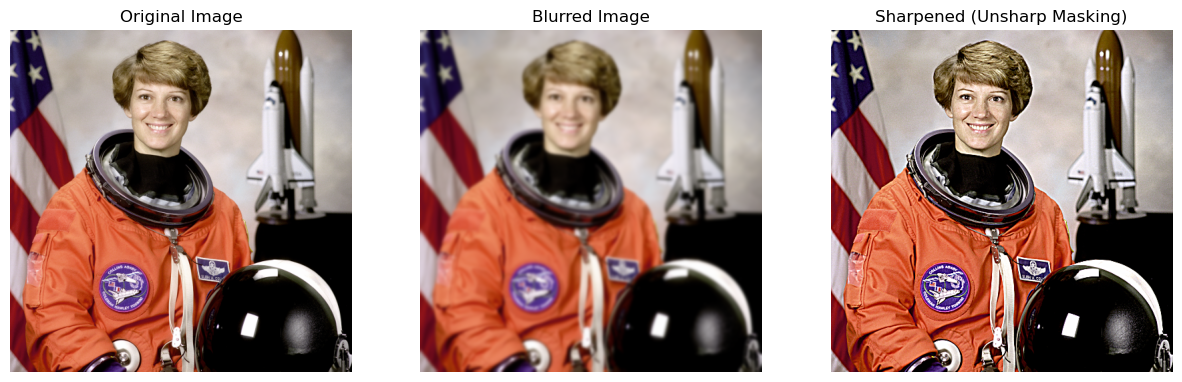

In [3]:
image = data.astronaut()

# Gaussian sigma (blur strength)
sigma = 2

# Sharpening strength
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);      ax[0].set_title("Original Image");              ax[0].axis("off")
ax[1].imshow(blurred);    ax[1].set_title("Blurred Image");               ax[1].axis("off")
ax[2].imshow(sharpened);  ax[2].set_title("Sharpened (Unsharp Masking)"); ax[2].axis("off")
plt.show()

---


## Assessment Task 1 — 7×7 Box Filter

A **box filter** is the simplest smoothing filter: every pixel is replaced by the **average** of the pixels in a square window around it. Every weight is equal — like a blurred "box" of influence.

A 7×7 box kernel looks like:

$$K = \frac{1}{49}\begin{bmatrix} 1 & 1 & \cdots & 1 \\ 1 & 1 & \cdots & 1 \\ \vdots & & \ddots & \vdots \\ 1 & 1 & \cdots & 1 \end{bmatrix}$$

All 49 entries are `1/49` so the weights sum to 1 (preserves average brightness).

**Effect:** Blurs the image and reduces noise. Downside: also blurs edges and produces slightly "blocky" results because of the equal weights.

Steps:
1) Build the kernel manually.
2) Apply convolution. `cv2.filter2D` is the general-purpose convolution function. It takes any kernel you give it and slides it across the image.


Kernel shape: (7, 7)
Each weight : 0.020408163 (= 1/49)
Sum of weights: 0.99999994


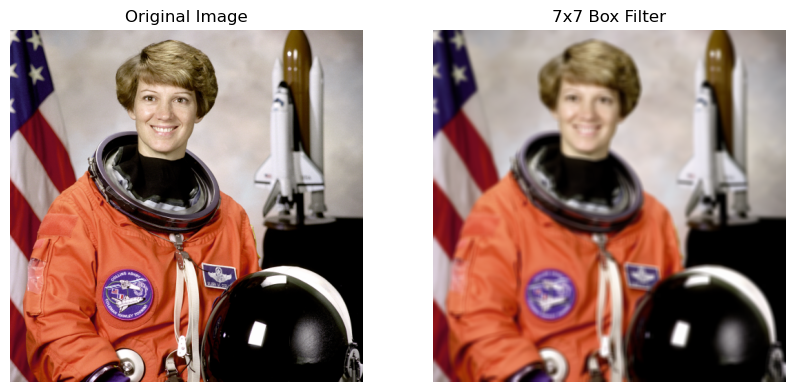

In [4]:
# Step 1:
kernel_box = np.ones((7, 7), dtype=np.float32) / 49.0
print("Kernel shape:", kernel_box.shape)
print("Each weight :", kernel_box[0, 0], "(= 1/49)")
print("Sum of weights:", kernel_box.sum())

# Step 2:
box_7x7 = cv2.filter2D(image_float, -1, kernel_box)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image);   ax[0].set_title("Original Image");   ax[0].axis("off")
ax[1].imshow(box_7x7); ax[1].set_title("7x7 Box Filter");   ax[1].axis("off")
plt.show()

## Assessment Task 2 — 5×5 and 21×21 Gaussian Filters

The **Gaussian filter** is a smarter blur than the box filter. Instead of giving all pixels equal weight, it weights **nearby pixels more** than far ones, following a 2D Gaussian (bell-curve) distribution:

$$G(x,y) = \frac{1}{2\pi\sigma^2}\, e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

A 5×5 Gaussian kernel (small blur):

$$\frac{1}{256}\begin{bmatrix}1 & 4 & 6 & 4 & 1\\4 & 16 & 24 & 16 & 4\\6 & 24 & 36 & 24 & 6\\4 & 16 & 24 & 16 & 4\\1 & 4 & 6 & 4 & 1\end{bmatrix}$$

**Why prefer Gaussian over box?**
- Smoother, more natural-looking blur (no blocky artifacts)
- Preserves edges slightly better for the same blur strength
- It's the mathematically optimal tradeoff between blurring and detail preservation

**Kernel size matters:**
- Small (e.g. 5×5) → gentle blur, subtle noise reduction
- Large (e.g. 21×21) → heavy blur, washes out fine detail

Kernel sum: 1.0
Max |GaussianBlur - manual kernel| = 2.9802322e-07


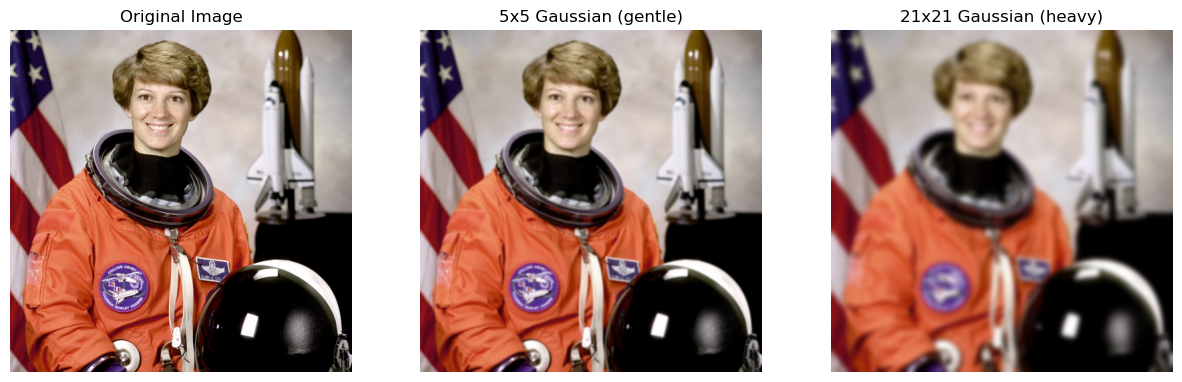

In [5]:
# Option A (normally used):
gauss_5x5  = cv2.GaussianBlur(image_float, (5, 5),   sigmaX=0)
gauss_21x21 = cv2.GaussianBlur(image_float, (21, 21), sigmaX=0)

# Option B (to understand what happens inside):
k1d = np.array([1, 4, 6, 4, 1], dtype=np.float32)
kernel_5x5 = np.outer(k1d, k1d) / 256.0
gauss_5x5_manual = cv2.filter2D(image_float, -1, kernel_5x5)

print("Kernel sum:", kernel_5x5.sum())
print("Max |GaussianBlur - manual kernel| =", np.abs(gauss_5x5 - gauss_5x5_manual).max())

# Plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);        ax[0].set_title("Original Image");        ax[0].axis("off")
ax[1].imshow(gauss_5x5);    ax[1].set_title("5x5 Gaussian (gentle)"); ax[1].axis("off")
ax[2].imshow(gauss_21x21);  ax[2].set_title("21x21 Gaussian (heavy)");ax[2].axis("off")
plt.show()

## Assessment Task 3 — 3×3 Laplacian Sharpening

The **Laplacian** is a *second-order* derivative operator that responds to rapid intensity changes (edges) from any direction. A common 3×3 Laplacian kernel:

$$K = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$

The Laplacian's raw output is **negative around bright edges and positive around dark ones**. By itself it doesn't look like an image — it looks like an edge map.

**Sharpening trick:**

$$\text{sharp} = \text{original} - \text{laplacian}$$

Subtracting the Laplacian from the original boosts edges. The result: the image looks the same, but edges pop more.

Steps (exactly as requested in the lab):
1. Read the image
2. Convert to `float32` (Laplacian can produce negatives)
3. Apply `cv2.Laplacian()`
4. Sharpen: `np.clip(image_float - laplacian, 0, 1)`
5. Plot the three images

Laplacian range: min = -2.592, max = 1.812


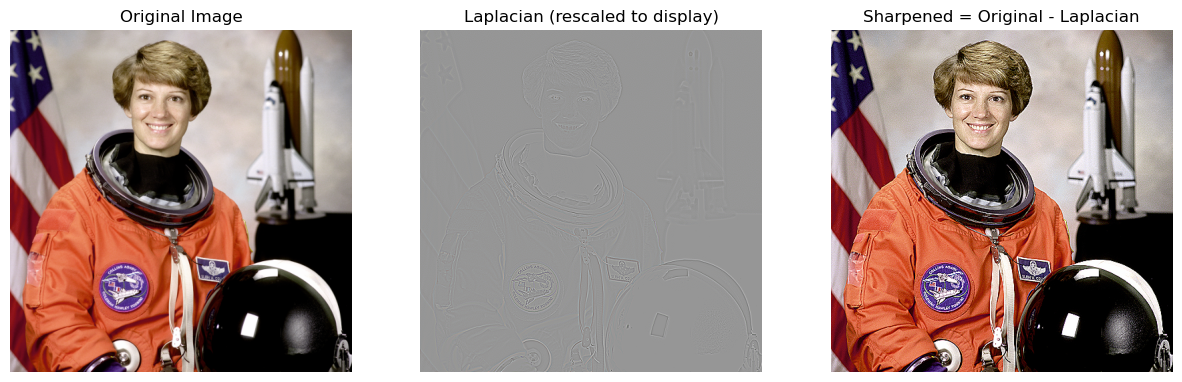

In [6]:
img = data.astronaut()
img_float = img.astype(np.float32) / 255.0

laplacian = cv2.Laplacian(img_float, cv2.CV_32F, ksize=1)

sharpened_lap = np.clip(img_float - laplacian, 0, 1)

# For display only:
lap_display = (laplacian - laplacian.min()) / (laplacian.max() - laplacian.min())

print("Laplacian range: min = %.3f, max = %.3f" % (laplacian.min(), laplacian.max()))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img);            ax[0].set_title("Original Image");                ax[0].axis("off")
ax[1].imshow(lap_display);    ax[1].set_title("Laplacian (rescaled to display)");ax[1].axis("off")
ax[2].imshow(sharpened_lap);  ax[2].set_title("Sharpened = Original - Laplacian");ax[2].axis("off")
plt.show()

## Q1 — Effect of Different Box Filter Sizes
Compare 3×3, 9×9, and 15×15 box filters. Bigger kernel = stronger blur = more detail lost.

Sharpness (variance of Laplacian)  -> higher = more detail
  Original : 0.01321
   3x3     : 0.00141
   9x9     : 9e-05
  15x15    : 2e-05


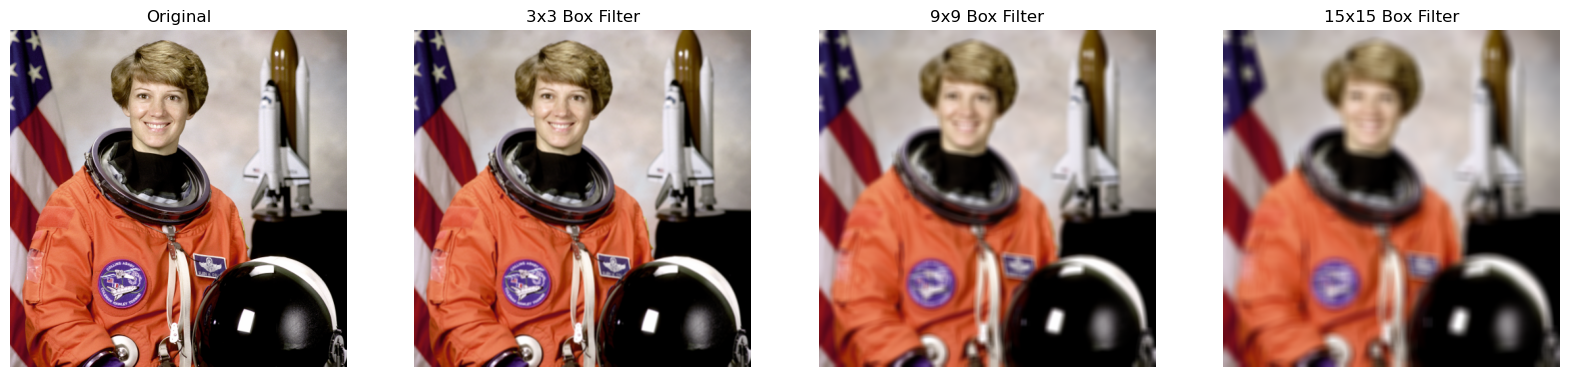

In [7]:
sizes = [3, 9, 15]
results = {}
for k in sizes:
    results[k] = cv2.blur(image_float, (k, k))

def sharpness(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_32F).var()

print("Sharpness (variance of Laplacian)  -> higher = more detail")
print("  Original :", round(float(sharpness(image_float)), 5))
for k in sizes:
    print(f"  {k:>2}x{k:<2}    :", round(float(sharpness(results[k])), 5))

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image); ax[0].set_title("Original"); ax[0].axis("off")
for i, k in enumerate(sizes, start=1):
    ax[i].imshow(results[k]); ax[i].set_title(f"{k}x{k} Box Filter"); ax[i].axis("off")
plt.show()

## Q2 — Median Filter: Removing Salt-and-Pepper Noise
The **median filter** replaces each pixel with the *median* of its neighborhood — not the mean. It's the best tool for removing "salt and pepper" noise (random black and white specks), because the median ignores extreme outliers.

Compare the median filter to a Gaussian blur on the same noisy image — Gaussian smears the specks, median removes them cleanly.

PSNR noisy    : 17.49 dB
PSNR gaussian : 25.39 dB
PSNR median   : 27.9 dB


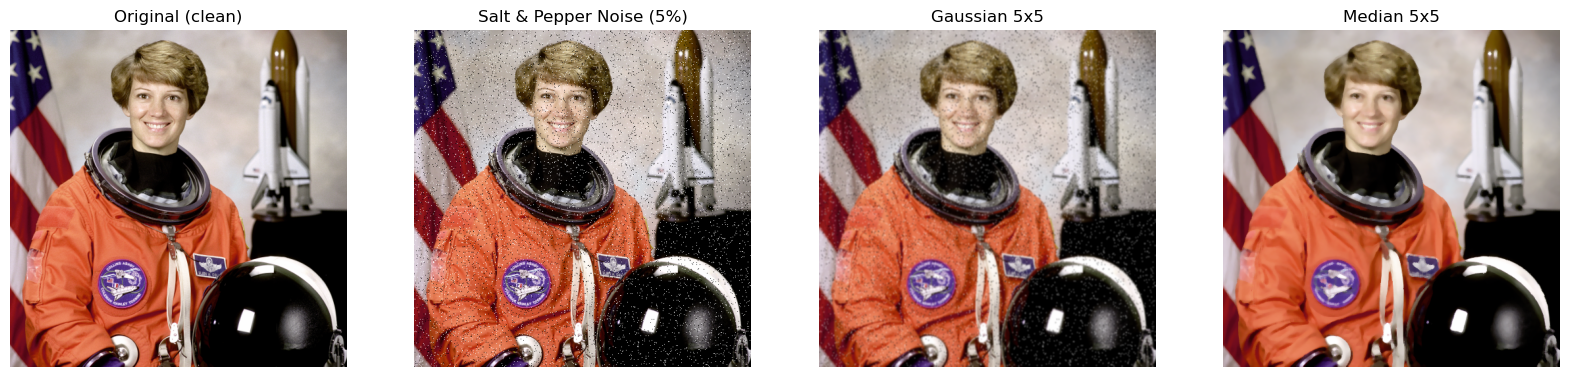

In [8]:
rng = np.random.default_rng(42)
noisy = image.copy()
amount_sp = 0.05
mask = rng.random(image.shape[:2])
noisy[mask < amount_sp / 2] = 0
noisy[mask > 1 - amount_sp / 2] = 255

gaussian_dn = cv2.GaussianBlur(noisy, (5, 5), 0)
median_dn   = cv2.medianBlur(noisy, 5)

print("PSNR noisy    :", round(cv2.PSNR(image, noisy), 2), "dB")
print("PSNR gaussian :", round(cv2.PSNR(image, gaussian_dn), 2), "dB")
print("PSNR median   :", round(cv2.PSNR(image, median_dn), 2), "dB")

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image);       ax[0].set_title("Original (clean)");        ax[0].axis("off")
ax[1].imshow(noisy);       ax[1].set_title("Salt & Pepper Noise (5%)");ax[1].axis("off")
ax[2].imshow(gaussian_dn); ax[2].set_title("Gaussian 5x5");            ax[2].axis("off")
ax[3].imshow(median_dn);   ax[3].set_title("Median 5x5");              ax[3].axis("off")
plt.show()

## Q3 — Bilateral Filter: Blurring While Keeping Edges Sharp
A normal Gaussian blur smooths everything — including edges. The **bilateral filter** is smarter: it blurs pixels only if they are close in *space* AND similar in *intensity*. Result: flat areas get smoothed, but edges stay crisp. Used in "beauty" filters, cartoon effects, and denoising.

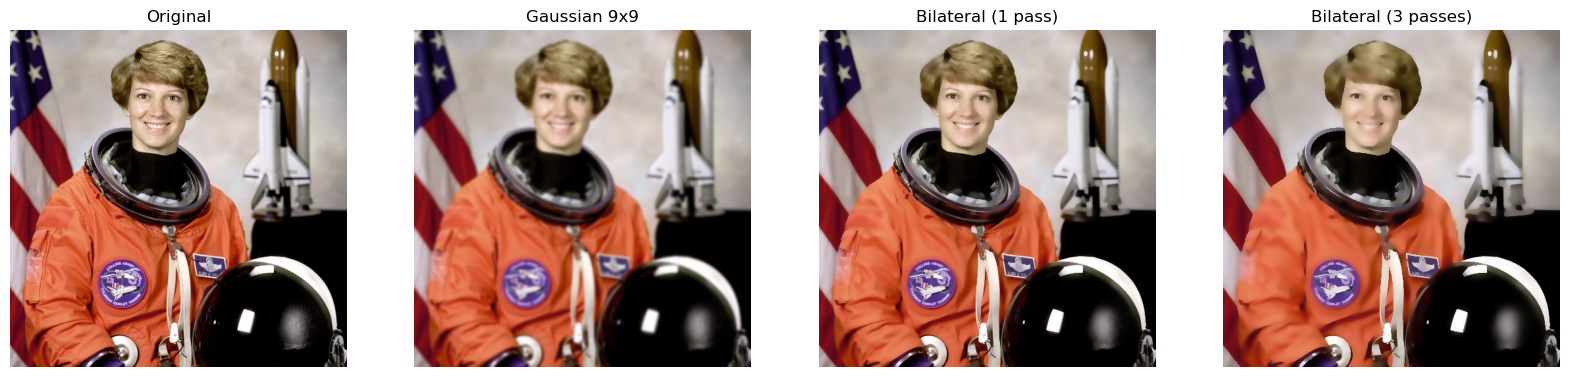

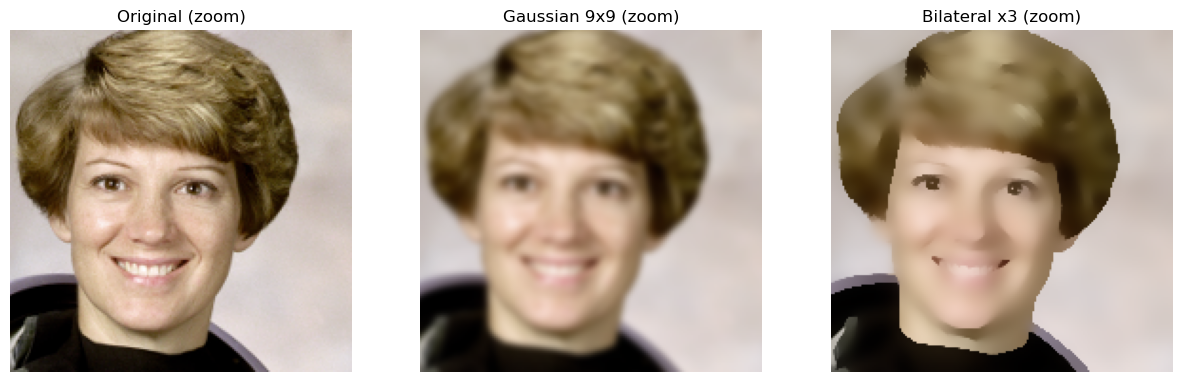

In [9]:
bilateral = cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

gaussian_9 = cv2.GaussianBlur(image, (9, 9), 0)

bilateral_strong = image.copy()
for _ in range(3):
    bilateral_strong = cv2.bilateralFilter(bilateral_strong, d=9, sigmaColor=75, sigmaSpace=75)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image);            ax[0].set_title("Original");                 ax[0].axis("off")
ax[1].imshow(gaussian_9);       ax[1].set_title("Gaussian 9x9");             ax[1].axis("off")
ax[2].imshow(bilateral);        ax[2].set_title("Bilateral (1 pass)");       ax[2].axis("off")
ax[3].imshow(bilateral_strong); ax[3].set_title("Bilateral (3 passes)");     ax[3].axis("off")
plt.show()

r0, r1, c0, c1 = 20, 200, 150, 330
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, im, t in zip(ax, [image, gaussian_9, bilateral_strong],
                    ["Original (zoom)", "Gaussian 9x9 (zoom)", "Bilateral x3 (zoom)"]):
    a.imshow(im[r0:r1, c0:c1]); a.set_title(t); a.axis("off")
plt.show()

---
## Summary Table

| Filter | Type | Effect | OpenCV function |
|---|---|---|---|
| **Box** | Smoothing (low-pass) | Simple average blur | `cv2.blur` or `cv2.filter2D` |
| **Gaussian** | Smoothing (low-pass) | Bell-curve weighted blur, smoother | `cv2.GaussianBlur` |
| **Median** | Smoothing (non-linear) | Removes salt-and-pepper noise | `cv2.medianBlur` |
| **Bilateral** | Smoothing (edge-preserving) | Blurs flat areas, keeps edges | `cv2.bilateralFilter` |
| **Laplacian** | Sharpening (high-pass) | Second-derivative edge enhance | `cv2.Laplacian` |
| **Unsharp mask** | Sharpening (combo) | Original + (original − blurred) | Custom (using `cv2.GaussianBlur`) |
| **Custom kernel** | Anything | Any effect you design | `cv2.filter2D` |

**Two rules to remember:**
1. For *smoothing* → use a low-pass filter (Box, Gaussian, Median, Bilateral).
2. For *sharpening* → amplify the high-frequency content (Laplacian, Unsharp mask, custom kernel with negative surround).

**End of notebook.**